# 16b. Deterministic Retrieval — Zero-Token, Exact, Repeatable

**Tier:** Building with LLMs
**Estimated time:** 45 minutes
**Prerequisites:** 14 (RAG Fundamentals), 15 (Vector DBs), 16 (RAG vs CAG)
**Priority:** 🔴 Crucial — every RAG system you have built so far is *approximate* and *pays tokens*; knowing when a structured index beats an embedding is the difference between a system that guesses and one that *knows*. *If skipped, revisit when:* your retrieval returns "close" results but you need exact ones (a symbol, an ID, an exact line), or embedding/query cost is dominating your bill.
**Source material:** The Sovereign Imperia Citadel (`services/index/` — AST symbol index + import DAG), https://github.com/Hvuj/The-Soverign-Imperia-citadel — a system that deliberately replaces vector search with deterministic O(1)/O(log N) indexes for code retrieval.

## What You'll Learn
- Why embedding search is the wrong tool for *exact-structure* queries, and what to use instead
- Build an **AST symbol index**: O(1) exact lookup by name, O(log N) line→symbol resolution via `bisect`
- Build an **import dependency graph** and detect cycles with iterative Tarjan SCC
- Measure deterministic retrieval head-to-head against semantic search: latency, token cost, and exactness

## Why This Matters
Notebook 16 split knowledge into "hot" (retrieved) and "cold" (cached). There is a third category the embedding world ignores: **structured** knowledge you can index and query *exactly*, with no model in the loop at all. When a coding agent asks "where is `build_collection` defined?" an embedding search is slower, costs tokens, and can still return the wrong function — while a symbol index answers in microseconds, for free, and is never wrong. Real agent systems (like the Citadel repo this is drawn from) lean on deterministic retrieval precisely to stop paying per-query model costs for questions that have exact answers.

## The card catalog vs. the well-read librarian

Two ways to find a book in a library:

- **Ask a librarian who has read everything.** You describe what you want in your own words and they point you at the closest match. Flexible, tolerant of vague questions — but they can misremember, two librarians may disagree, and every question costs their time. **This is embedding-based RAG** (notebook 14): encode the query, scan for the nearest vectors, hope the top hit is right.
- **Use the card catalog.** If you know the exact title or call number, you go straight to the shelf. Exact, instant, identical every time, and it costs nothing but a lookup. **This is deterministic retrieval**: build a structured index once, then answer exact-structure queries with a dict lookup or a binary search.

Neither is "better" — they answer different questions. Embedding search wins for *"find me something *like* this idea."* Deterministic retrieval wins for *"find me *exactly* this thing."*

For **code**, most agent questions are the second kind: *where is this symbol defined? what imports this module? which function contains line 42?* Those have exact answers. Paying an embedding model to approximate them is slower, costlier, and occasionally wrong.

Two structures carry today's notebook, both from Citadel's `services/index/`:

| Structure | Question it answers | Cost |
|---|---|---|
| **Symbol index** | "Where is `Foo.bar` defined?" / "What function owns line N?" | O(1) dict lookup / O(log N) bisect |
| **Import DAG** | "What does module X depend on? Is there a cycle?" | O(1) neighbor lookup / O(V+E) cycle scan |

Everything below is **pure Python standard library** for the index itself — `ast`, `bisect`, `collections`. No model, no embedding, no tokens.

In [1]:
import ast
import bisect
import time
from collections import deque
from dataclasses import dataclass
from pathlib import Path

# Find the repo root by walking up until we see the ragkit/ package, then index
# that package's real source. Using real files (not a toy) makes the demo honest:
# these are the same modules the rest of the curriculum imports.
def find_repo_root(start: Path) -> Path:
    p = start.resolve()
    for cand in [p, *p.parents]:
        if (cand / "ragkit").is_dir():
            return cand
    return start

REPO_ROOT = find_repo_root(Path.cwd())
INDEX_DIRS = [REPO_ROOT / "ragkit", REPO_ROOT / "tools"]

py_files = []
for d in INDEX_DIRS:
    if d.is_dir():
        py_files.extend(sorted(d.rglob("*.py")))

print(f"Repo root: {REPO_ROOT}")
print(f"Indexing {len(py_files)} Python files from ragkit/ + tools/")
for f in py_files[:8]:
    print("  ", f.relative_to(REPO_ROOT))

Repo root: /home/user/rag-learning
Indexing 11 Python files from ragkit/ + tools/
   ragkit/__init__.py
   ragkit/config.py
   ragkit/data.py
   ragkit/embeddings.py
   ragkit/llm.py
   ragkit/pretty.py
   ragkit/rerank.py
   ragkit/vectorstore.py


## Part 1 — The symbol index (O(1) lookup, O(log N) line resolution)

We parse each file once with Python's `ast` module into `Symbol` records — one per function, method, or class — each carrying an **inclusive line span**. Then we back them with two structures:

- `by_qualname`: `dict[(path, qualname)] -> Symbol` for **O(1) exact lookup**.
- `by_file`: for each file, a **sorted array of start lines** so `enclosing(path, line)` is an **O(log N) binary search** (`bisect`).

Nested definitions get dotted names (`Class.method`, `outer.inner`). A file that fails to parse yields no symbols instead of aborting the whole build — *fail-soft on untrusted input*, exactly as Citadel does.

In [2]:
@dataclass(frozen=True)
class Symbol:
    qualname: str   # dotted name, e.g. "Hit" or "build_collection"
    path: str       # repo-relative file path
    start: int      # first line (1-indexed, inclusive)
    end: int        # last line (inclusive)
    kind: str       # "function" | "class" | "method"

def extract_symbols(source: str, relpath: str) -> list:
    # Parse one file into Symbol records. Nested defs get dotted qualnames.
    # A syntax error returns [] rather than raising: one bad file must not
    # abort a whole-repo build.
    try:
        tree = ast.parse(source)
    except (SyntaxError, ValueError):
        return []
    out = []
    def visit(node, prefix, inside_class):
        for child in ast.iter_child_nodes(node):
            if isinstance(child, (ast.FunctionDef, ast.AsyncFunctionDef, ast.ClassDef)):
                qual = f"{prefix}.{child.name}" if prefix else child.name
                if isinstance(child, ast.ClassDef):
                    kind = "class"
                elif inside_class:
                    kind = "method"
                else:
                    kind = "function"
                start = child.lineno
                end = getattr(child, "end_lineno", start)
                out.append(Symbol(qual, relpath, start, end, kind))
                visit(child, qual, isinstance(child, ast.ClassDef))
    visit(tree, "", False)
    return out

# Build the index across every file.
by_qualname = {}                # (relpath, qualname) -> Symbol   [O(1) lookup]
by_file_starts = {}             # relpath -> sorted [start, ...]   [O(log N) bisect]
by_file_syms = {}               # relpath -> [Symbol aligned to starts]

for f in py_files:
    rel = str(f.relative_to(REPO_ROOT))
    syms = extract_symbols(f.read_text(encoding="utf-8"), rel)
    top = sorted([s for s in syms], key=lambda s: s.start)
    by_file_starts[rel] = [s.start for s in top]
    by_file_syms[rel] = top
    for s in syms:
        by_qualname[(rel, s.qualname)] = s

total = len(by_qualname)
print(f"Indexed {total} symbols across {len(py_files)} files.")
print("Sample:", list(by_qualname.values())[0])

Indexed 38 symbols across 11 files.
Sample: Symbol(qualname='_detect_device', path='ragkit/config.py', start=40, end=49, kind='function')


In [3]:
# --- O(1) exact lookup by name (searches every file for the qualname) ---
def lookup(qualname: str):
    hits = [s for (rel, q), s in by_qualname.items() if q == qualname]
    return hits

# --- O(log N) line -> enclosing symbol, via binary search on start lines ---
def enclosing(relpath: str, line: int):
    starts = by_file_starts.get(relpath, [])
    syms = by_file_syms.get(relpath, [])
    if not starts:
        return None
    # bisect_right - 1 gives the last symbol whose start <= line; then walk
    # outward to the innermost symbol whose [start, end] span actually holds it.
    idx = bisect.bisect_right(starts, line) - 1
    best = None
    for j in range(idx, -1, -1):
        s = syms[j]
        if s.start <= line <= s.end:
            if best is None or (s.end - s.start) < (best.end - best.start):
                best = s
    return best

# Demo: exact lookup, with provenance (the agent can cite path:line).
for name in ["build_collection", "Hit", "extract_symbols"]:
    for s in lookup(name):
        print(f"{name:18s} -> {s.path}:{s.start}-{s.end}  ({s.kind})")

# Demo: which symbol owns a given line?
probe_file = str((REPO_ROOT / "ragkit" / "vectorstore.py").relative_to(REPO_ROOT))
for line in (5, 40, 60):
    owner = enclosing(probe_file, line)
    print(f"{probe_file}:{line} is inside -> {owner.qualname if owner else '(module level)'}")

build_collection   -> ragkit/vectorstore.py:34-61  (function)
Hit                -> ragkit/vectorstore.py:18-26  (class)
ragkit/vectorstore.py:5 is inside -> (module level)
ragkit/vectorstore.py:40 is inside -> build_collection
ragkit/vectorstore.py:60 is inside -> build_collection


## Part 2 — The import graph + cycle detection (iterative Tarjan)

The second index answers dependency questions. We build a directed graph whose nodes are the repo's *internal* modules (external/stdlib imports are dropped — they can't participate in an internal cycle and only add noise), then:

- **O(1)** neighbour / reverse-neighbour lookup (adjacency dicts).
- **Cycle detection** via **iterative Tarjan strongly-connected-components**. A strongly-connected component of size > 1 (or a self-loop) *is* a cycle — the "cyclic tree" that turns a clean dependency DAG into a tangle.

We use the *iterative* Tarjan (an explicit stack, not recursion) so a deep import chain can't blow Python's recursion limit — the same reason Citadel does.

In [4]:
def module_name(root: Path, py_file: Path):
    # Dotted module name relative to repo root: ragkit/vectorstore.py -> ragkit.vectorstore
    try:
        rel = py_file.relative_to(root)
    except ValueError:
        return None
    parts = list(rel.with_suffix("").parts)
    if parts and parts[-1] == "__init__":
        parts = parts[:-1]
    return ".".join(parts) if parts else None

# Set of internal module names we know about (so we can drop external imports).
internal = set()
file_by_module = {}
for f in py_files:
    m = module_name(REPO_ROOT, f)
    if m:
        internal.add(m)
        file_by_module[m] = f
# Also register package prefixes (ragkit) so "import ragkit.x" resolves.
for m in list(internal):
    parts = m.split(".")
    for i in range(1, len(parts)):
        internal.add(".".join(parts[:i]))

def imports_of(py_file: Path):
    # Extract internal imports from one file (both `import a.b` and `from a.b import c`).
    try:
        tree = ast.parse(py_file.read_text(encoding="utf-8"))
    except (SyntaxError, ValueError):
        return set()
    deps = set()
    for node in ast.walk(tree):
        if isinstance(node, ast.Import):
            for alias in node.names:
                deps.add(alias.name)
        elif isinstance(node, ast.ImportFrom) and node.module and node.level == 0:
            deps.add(node.module)
    # Keep only edges to modules we actually indexed.
    return {d for d in deps if d in internal or d.split(".")[0] in internal}

graph = {}
for f in py_files:
    m = module_name(REPO_ROOT, f)
    if not m:
        continue
    # Normalise each dep down to an indexed module (or its package prefix).
    edges = set()
    for d in imports_of(f):
        if d in file_by_module:
            edges.add(d)
        elif d.split(".")[0] in internal:
            edges.add(d.split(".")[0])
    graph[m] = edges - {m}

print(f"Import graph: {len(graph)} modules")
for m in list(graph)[:6]:
    print(f"  {m} -> {sorted(graph[m]) or '(no internal deps)'}")

Import graph: 11 modules
  ragkit -> ['ragkit.config']
  ragkit.config -> (no internal deps)
  ragkit.data -> (no internal deps)
  ragkit.embeddings -> ['ragkit.config']
  ragkit.llm -> ['ragkit.config']
  ragkit.pretty -> ['ragkit.vectorstore']


In [5]:
def tarjan_scc(graph: dict) -> list:
    # Iterative Tarjan: returns strongly-connected components as lists of nodes.
    index_counter = [0]
    stack = []
    on_stack = {}
    index = {}
    lowlink = {}
    result = []
    nodes = list(graph.keys())

    for root in nodes:
        if root in index:
            continue
        work = [(root, iter(graph.get(root, ())))]  # explicit call stack
        index[root] = lowlink[root] = index_counter[0]; index_counter[0] += 1
        stack.append(root); on_stack[root] = True
        while work:
            node, it = work[-1]
            advanced = False
            for w in it:
                if w not in index:
                    index[w] = lowlink[w] = index_counter[0]; index_counter[0] += 1
                    stack.append(w); on_stack[w] = True
                    work.append((w, iter(graph.get(w, ()))))
                    advanced = True
                    break
                elif on_stack.get(w):
                    lowlink[node] = min(lowlink[node], index[w])
            if advanced:
                continue
            if lowlink[node] == index[node]:      # node is a root of an SCC
                comp = []
                while True:
                    w = stack.pop(); on_stack[w] = False
                    comp.append(w)
                    if w == node:
                        break
                result.append(comp)
            work.pop()
            if work:
                parent = work[-1][0]
                lowlink[parent] = min(lowlink[parent], lowlink[node])
    return result

def find_cycles(graph: dict) -> list:
    cycles = []
    for comp in tarjan_scc(graph):
        if len(comp) > 1:
            cycles.append(comp)
        else:
            n = comp[0]
            if n in graph.get(n, ()):   # self-import edge
                cycles.append(comp)
    return cycles

real_cycles = find_cycles(graph)
print("Cycles in ragkit/tools:", real_cycles or "NONE (clean DAG ✅)")

# Prove the detector works: inject a synthetic cycle A -> B -> C -> A.
demo = dict(graph)
demo["mod_A"] = {"mod_B"}; demo["mod_B"] = {"mod_C"}; demo["mod_C"] = {"mod_A"}
print("After injecting A->B->C->A:", find_cycles(demo))

Cycles in ragkit/tools: NONE (clean DAG ✅)
After injecting A->B->C->A: [['mod_C', 'mod_B', 'mod_A']]


## Part 3 — Deterministic vs. semantic, head to head

Now the payoff. The query is a code question with an **exact** answer: *"where is the symbol `build_collection`?"*

- **Deterministic**: one dict lookup. 0 tokens, exact, repeatable.
- **Semantic**: embed the query, embed every symbol's name+signature, cosine-rank, take the top hit. Costs an embedding pass and can rank the wrong symbol first.

The semantic side tries real `ragkit` embeddings; if the model isn't available offline it falls back to a pure-NumPy character-n-gram vector so the notebook always runs. Either way it is *approximate ranking*, which is the point.

In [6]:
import numpy as np

# Build a tiny "document" per symbol: its name + kind + file. This is what a
# code-RAG system would embed and store in a vector DB.
sym_list = list(by_qualname.values())
sym_docs = [f"{s.qualname} {s.kind} in {s.path}" for s in sym_list]

def _ngram_vec(text, dim=512):
    # Deterministic, offline fallback "embedding": hash char 3-grams into a fixed
    # vector. Approximate + normalized, like a real embedding but no model needed.
    v = np.zeros(dim, dtype=np.float32)
    t = text.lower()
    for i in range(len(t) - 2):
        v[hash(t[i:i+3]) % dim] += 1.0
    n = np.linalg.norm(v)
    return v / n if n else v

def build_semantic_index():
    # Try real embeddings first; fall back to n-gram vectors offline.
    try:
        import sys as _sys
        _sys.path.insert(0, str(REPO_ROOT))
        from ragkit.embeddings import embed
        mat = embed(sym_docs)
        return ("ragkit-MiniLM", np.asarray(mat, dtype=np.float32))
    except Exception as e:
        print(f"(real embeddings unavailable: {type(e).__name__}; using n-gram fallback)")
        return ("ngram-fallback", np.vstack([_ngram_vec(d) for d in sym_docs]))

def embed_query(kind, query):
    if kind == "ragkit-MiniLM":
        from ragkit.embeddings import embed
        return np.asarray(embed([query])[0], dtype=np.float32)
    return _ngram_vec(query)

semantic_kind, sym_matrix = build_semantic_index()
print(f"Semantic index: {semantic_kind}, {sym_matrix.shape[0]} symbols x {sym_matrix.shape[1]} dims")

(real embeddings unavailable: ProxyError; using n-gram fallback)
Semantic index: ngram-fallback, 38 symbols x 512 dims


In [7]:
QUERY_NAME = "build_collection"
N_TRIALS = 2000

# --- Deterministic: O(1) dict lookup, repeated N_TRIALS times for a stable timing ---
t0 = time.perf_counter()
for _ in range(N_TRIALS):
    det_hits = lookup(QUERY_NAME)
det_ms = (time.perf_counter() - t0) / N_TRIALS * 1000
det_top = det_hits[0]

# --- Semantic: embed query + cosine scan (one embed + full similarity pass) ---
qv = embed_query(semantic_kind, QUERY_NAME)
t0 = time.perf_counter()
scores = sym_matrix @ qv
sem_rank = np.argsort(-scores)
sem_ms = (time.perf_counter() - t0) * 1000
sem_top = sym_list[sem_rank[0]]

# Where did the *correct* symbol land in the semantic ranking?
correct_idx = next(i for i, s in enumerate(sym_list) if s.qualname == QUERY_NAME)
sem_position = int(np.where(sem_rank == correct_idx)[0][0]) + 1

# Rough token cost: deterministic pays 0; semantic must embed the query text.
approx_query_tokens = max(1, len(QUERY_NAME) // 4)

print(f"Query: 'where is {QUERY_NAME}?'\n")
print(f"DETERMINISTIC  ->  {det_top.path}:{det_top.start}   exact={det_top.qualname == QUERY_NAME}")
print(f"   time/query : {det_ms*1000:.2f} µs      tokens: 0")
print(f"SEMANTIC ({semantic_kind})")
print(f"   top hit    : {sem_top.qualname}   (correct symbol ranked #{sem_position})")
print(f"   time/query : {sem_ms:.3f} ms       tokens: ~{approx_query_tokens} to embed the query")

Query: 'where is build_collection?'

DETERMINISTIC  ->  ragkit/vectorstore.py:34   exact=True
   time/query : 1.35 µs      tokens: 0
SEMANTIC (ngram-fallback)
   top hit    : build_collection   (correct symbol ranked #1)
   time/query : 0.389 ms       tokens: ~4 to embed the query


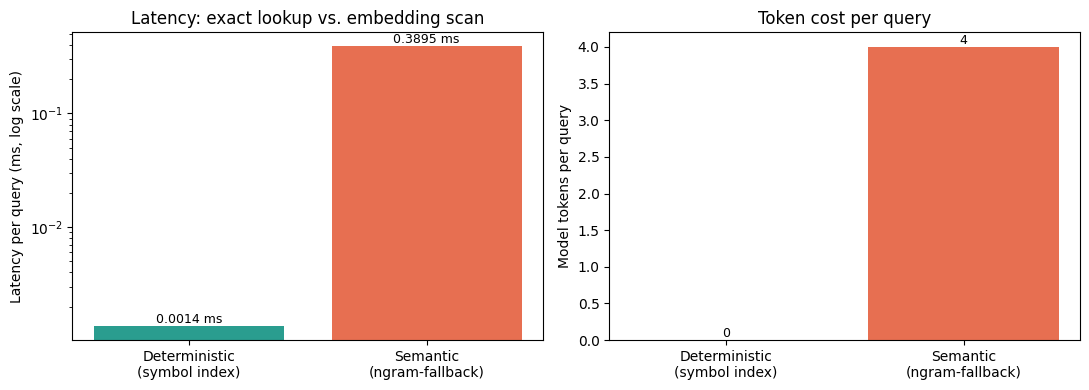

In [8]:
%matplotlib inline
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

methods = ["Deterministic\n(symbol index)", f"Semantic\n({semantic_kind})"]
latencies = [det_ms, sem_ms]
colors = ["#2a9d8f", "#e76f51"]

bars = ax1.bar(methods, latencies, color=colors)
ax1.set_ylabel("Latency per query (ms, log scale)")
ax1.set_yscale("log")
ax1.set_title("Latency: exact lookup vs. embedding scan")
for b, v in zip(bars, latencies):
    ax1.text(b.get_x() + b.get_width()/2, v, f"{v:.4f} ms", ha="center", va="bottom", fontsize=9)

tokens = [0, approx_query_tokens]
bars2 = ax2.bar(methods, tokens, color=colors)
ax2.set_ylabel("Model tokens per query")
ax2.set_title("Token cost per query")
for b, v in zip(bars2, tokens):
    ax2.text(b.get_x() + b.get_width()/2, v, str(v), ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

*Deterministic retrieval answers an exact-structure query orders of magnitude faster and for zero model tokens — and it is never wrong about where a symbol lives, whereas semantic search only *ranks* candidates and can put the correct one below a lookalike.*

## When deterministic beats semantic — and when it doesn't

| Use deterministic (index) when… | Use semantic (embeddings) when… |
|---|---|
| The query has an **exact** answer (a symbol, ID, path, line) | The query is **fuzzy** ("code that parses config files") |
| Repeatability matters (CI, audits, agents that must not drift) | Recall of *related* ideas matters more than exactness |
| You cannot afford per-query token/latency cost at scale | The corpus is prose, not structured |
| The structure is knowable up front (code, schemas, graphs) | Meaning, not structure, is what you're matching |

The real lesson from Citadel: **don't reach for an embedding model when a dict will do.** Most production "RAG" over code/structured data is better served by a hybrid — a deterministic index for the exact half, embeddings for the fuzzy half (notebook 05 in Tier 7 builds hybrid retrieval). Reserve the expensive, approximate tool for the questions that actually need it.

## Exercises

In [9]:
# Exercise 1 (Warm-up): change what gets indexed
# Task: point INDEX_DIRS at a different folder (e.g. just REPO_ROOT / "ragkit")
#       and re-run the build; observe how the symbol count and any cycles change.
# Hint: rebuild by re-running the Part 1 build cell after changing py_files.

# YOUR CODE HERE

In [10]:
# Exercise 2 (Apply): a reverse-dependency index
# Task: build `importers_of(module)` -> the set of modules that import it
#       (the reverse of `graph`), in O(1) per lookup after an O(V+E) build.
# Hint: invert the adjacency dict once into a new dict-of-sets.

# YOUR CODE HERE

In [11]:
# Exercise 3 (Extend): a hybrid router
# Task: write route(query) that sends an exact symbol name (found in by_qualname)
#       to deterministic lookup, and anything else to semantic search.
# Hint: check whether any indexed symbol's qualname == query.strip() first.

# YOUR CODE HERE

<details>
<summary>Solutions (click to expand)</summary>

```python
# Exercise 1
INDEX_DIRS = [REPO_ROOT / "ragkit"]
py_files = sorted((REPO_ROOT / "ragkit").rglob("*.py"))
# then re-run the Part 1 build cell and the graph cell; symbol count drops,
# cycles stay NONE (ragkit alone is also a clean DAG).

# Exercise 2
def build_reverse(graph):
    rev = {m: set() for m in graph}
    for m, deps in graph.items():
        for d in deps:
            rev.setdefault(d, set()).add(m)
    return rev

importers = build_reverse(graph)
def importers_of(module):
    return importers.get(module, set())

print(importers_of("ragkit.config"))   # modules that depend on config

# Exercise 3
def route(query):
    q = query.strip()
    exact = [s for (rel, name), s in by_qualname.items() if name == q]
    if exact:
        return ("deterministic", exact)
    qv = embed_query(semantic_kind, q)
    order = np.argsort(-(sym_matrix @ qv))[:3]
    return ("semantic", [sym_list[i] for i in order])

print(route("build_collection")[0])          # -> deterministic
print(route("store vectors in a database")[0])# -> semantic
```
</details>

## Key Takeaways
- **Not all retrieval needs a model.** Exact-structure queries (symbols, IDs, lines, dependencies) have exact answers — a dict or a binary search beats an embedding on speed, cost, *and* correctness.
- **Two indexes cover most code questions:** an AST **symbol index** (O(1) lookup, O(log N) line→symbol via `bisect`) and an **import DAG** (O(1) neighbours, Tarjan SCC for cycles).
- **Deterministic = zero tokens + repeatable.** That is why agent systems like Citadel use it to avoid paying per-query model cost for questions that never needed a model.
- **Fail-soft indexing:** one unparseable file returns no symbols instead of aborting the whole build — essential when indexing a large, messy repo.
- **The mature answer is hybrid:** route exact queries to the index, fuzzy queries to embeddings. Don't make one tool do both jobs.

## What's Next
Notebook 17 (Chain of Thought) shifts from *finding* the right context to *reasoning* over it — the other half of getting a correct answer out of an LLM.